In [2]:
import os
import glob
import zipfile
import pandas as pd
import numpy as np

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Rata rata lama sekolah.zip to Rata rata lama sekolah.zip
Saving Literacy Rate of The Age Population.zip to Literacy Rate of The Age Population.zip


In [5]:
import zipfile

zipfile.ZipFile("Rata rata lama sekolah.zip").extractall("RLS")

zipfile.ZipFile("Literacy Rate of The Age Population.zip").extractall("AMH")

print("Extract selesai")

Extract selesai


In [6]:
print("Jumlah File RLS :",len(glob.glob("RLS/**/*.csv",recursive=True)))

print("Jumlah File AMH :",len(glob.glob("AMH/**/*.csv",recursive=True)))

Jumlah File RLS : 16
Jumlah File AMH : 16


In [8]:
import glob
import pandas as pd

files = sorted(glob.glob("RLS/**/*.csv", recursive=True))

print("Jumlah file :", len(files))

for file in files:
    print("="*80)
    print(file)

    df = pd.read_csv(file)

    print(df.head(10))

Jumlah file : 16
RLS/Rata rata lama sekolah/[Metode Baru] Rata-Rata Lama Sekolah Menurut Kabupaten_Kota di Provinsi Sumatera Barat, 2010.csv
            Kabupaten/Kota                                         Unnamed: 1
0                      NaN  [Metode Baru] Rata-Rata Lama Sekolah Menurut K...
1                      NaN                                               2010
2  Kab. Kepulauan Mentawai                                               6.14
3     Kab. Pesisir Selatan                                               7.34
4               Kab. Solok                                               7.16
5           Kab. Sijunjung                                               7.09
6         Kab. Tanah Datar                                               7.48
7     Kab. Padang Pariaman                                               6.62
8                Kab. Agam                                               7.56
9     Kab. Lima Puluh Kota                                               7.37
R

In [9]:
import glob
import pandas as pd
import re

rls_list = []

files = sorted(glob.glob("RLS/**/*.csv", recursive=True))

for file in files:

    # Ambil tahun dari nama file
    tahun = int(re.search(r'20\d{2}', file).group())

    # Baca file
    df = pd.read_csv(file)

    # Ambil hanya data kabupaten (19 baris)
    df = df.iloc[2:21].copy()

    # Rename kolom
    df.columns = ["Kabupaten_Kota", "RLS"]

    # Tambahkan tahun
    df["Tahun"] = tahun

    rls_list.append(df)

# Gabungkan
rls = pd.concat(rls_list, ignore_index=True)

print(rls.shape)

display(rls.head())

(304, 3)


,Kabupaten_Kota,RLS,Tahun
0,Kab. Kepulauan Mentawai,6.14,2010
1,Kab. Pesisir Selatan,7.34,2010
2,Kab. Solok,7.16,2010
3,Kab. Sijunjung,7.09,2010
4,Kab. Tanah Datar,7.48,2010


In [10]:
print(sorted(rls["Tahun"].unique()))

[np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [11]:
print(rls.groupby("Tahun").size())

Tahun
2010    19
2011    19
2012    19
2013    19
2014    19
2015    19
2016    19
2017    19
2018    19
2019    19
2020    19
2021    19
2022    19
2023    19
2024    19
2025    19
dtype: int64


In [12]:
import glob
import pandas as pd

files = sorted(glob.glob("AMH/**/*.csv", recursive=True))

print(files[0])

df = pd.read_csv(files[0])

display(df.head(15))

AMH/Literacy Rate of The Age Population/Literacy Rate of The Age Population 15-64 Years by Regency_Municipality and Sex in Sumatera Barat Province, 2010.csv


,Regency/Municipality,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,Literacy Rate of The Age Population 15-64 Year...,NaN,NaN
1,NaN,Man,Woman,Man+Woman
2,NaN,2010,2010,2010
3,Kepulauan Mentawai Regency,96.95,93.77,95.44
4,Pesisir Selatan Regency,97.76,97.58,97.67
5,Solok Regency,97.13,96.87,96.99
6,Sijunjung Regency,97.61,95.25,96.39
7,Tanah Datar Regency,98.27,98.28,98.28
8,Padang Pariaman Regency,97.96,93.69,95.78
9,Agam Regency,98.66,97.43,98.03


In [13]:
import glob
import pandas as pd
import re

amh_list = []

files = sorted(glob.glob("AMH/**/*.csv", recursive=True))

for file in files:

    tahun = int(re.search(r'20\d{2}', file).group())

    df = pd.read_csv(file)

    # Ambil 19 kabupaten
    df = df.iloc[3:22,[0,3]].copy()

    df.columns = ["Kabupaten_Kota","AMH"]

    df["Tahun"] = tahun

    amh_list.append(df)

amh = pd.concat(amh_list,ignore_index=True)

print(amh.shape)

display(amh.head())

(304, 3)


,Kabupaten_Kota,AMH,Tahun
0,Kepulauan Mentawai Regency,95.44,2010
1,Pesisir Selatan Regency,97.67,2010
2,Solok Regency,96.99,2010
3,Sijunjung Regency,96.39,2010
4,Tanah Datar Regency,98.28,2010


In [14]:
mapping = {

"Kepulauan Mentawai Regency":"Kab. Kepulauan Mentawai",
"Pesisir Selatan Regency":"Kab. Pesisir Selatan",
"Solok Regency":"Kab. Solok",
"Sijunjung Regency":"Kab. Sijunjung",
"Tanah Datar Regency":"Kab. Tanah Datar",
"Padang Pariaman Regency":"Kab. Padang Pariaman",
"Agam Regency":"Kab. Agam",
"Lima Puluh Kota Regency":"Kab. Lima Puluh Kota",
"Pasaman Regency":"Kab. Pasaman",
"Solok Selatan Regency":"Kab. Solok Selatan",
"Dharmasraya Regency":"Kab. Dharmasraya",
"Pasaman Barat Regency":"Kab. Pasaman Barat",
"Padang City":"Kota Padang",
"Solok City":"Kota Solok",
"Sawah Lunto City":"Kota Sawahlunto",
"Padang Panjang City":"Kota Padang Panjang",
"Bukittinggi City":"Kota Bukittinggi",
"Payakumbuh City":"Kota Payakumbuh",
"Pariaman City":"Kota Pariaman"

}

amh["Kabupaten_Kota"] = amh["Kabupaten_Kota"].replace(mapping)

In [15]:
education = pd.merge(
    rls,
    amh,
    on=["Kabupaten_Kota","Tahun"],
    how="inner"
)

education["RLS"] = pd.to_numeric(education["RLS"])

education["AMH"] = pd.to_numeric(education["AMH"])

education = education.sort_values(
    ["Kabupaten_Kota","Tahun"]
).reset_index(drop=True)

education.head()

,Kabupaten_Kota,RLS,Tahun,AMH
0,Kab. Agam,7.56,2010,98.03
1,Kab. Agam,7.68,2011,97.91
2,Kab. Agam,7.91,2012,98.04
3,Kab. Agam,8.09,2013,99.11
4,Kab. Agam,8.10,2014,99.48


In [16]:
print("Shape :", education.shape)

print("\nTahun")
print(sorted(education["Tahun"].unique()))

print("\nJumlah Data per Kabupaten")
print(education.groupby("Kabupaten_Kota").size())

Shape : (192, 4)

Tahun
[np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Jumlah Data per Kabupaten
Kabupaten_Kota
Kab. Agam                  16
Kab. Dharmasraya           16
Kab. Kepulauan Mentawai    16
Kab. Lima Puluh Kota       16
Kab. Padang Pariaman       16
Kab. Pasaman               16
Kab. Pasaman Barat         16
Kab. Pesisir Selatan       16
Kab. Sijunjung             16
Kab. Solok                 16
Kab. Solok Selatan         16
Kab. Tanah Datar           16
dtype: int64


In [17]:
print("Shape :", education.shape)

print("\nTahun")
print(sorted(education["Tahun"].unique()))

print("\nJumlah Data per Kabupaten")
print(education.groupby("Kabupaten_Kota").size())

Shape : (192, 4)

Tahun
[np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Jumlah Data per Kabupaten
Kabupaten_Kota
Kab. Agam                  16
Kab. Dharmasraya           16
Kab. Kepulauan Mentawai    16
Kab. Lima Puluh Kota       16
Kab. Padang Pariaman       16
Kab. Pasaman               16
Kab. Pasaman Barat         16
Kab. Pesisir Selatan       16
Kab. Sijunjung             16
Kab. Solok                 16
Kab. Solok Selatan         16
Kab. Tanah Datar           16
dtype: int64


In [18]:
# Kabupaten yang ada di RLS tetapi tidak ada di AMH
print("Ada di RLS, tidak ada di AMH:")
print(sorted(set(rls["Kabupaten_Kota"]) - set(amh["Kabupaten_Kota"])))

print("\n" + "="*50 + "\n")

# Kabupaten yang ada di AMH tetapi tidak ada di RLS
print("Ada di AMH, tidak ada di RLS:")
print(sorted(set(amh["Kabupaten_Kota"]) - set(rls["Kabupaten_Kota"])))

Ada di RLS, tidak ada di AMH:
['Kota Bukittinggi', 'Kota Padang', 'Kota Padang Panjang', 'Kota Pariaman', 'Kota Payakumbuh', 'Kota Sawahlunto', 'Kota Solok']


Ada di AMH, tidak ada di RLS:
['Bukittinggi Municipality', 'Padang Municipality', 'Padang Panjang Municipality', 'Pariaman Municipality', 'Payakumbuh Municipality', 'Sawahlunto Municipality', 'Solok Municipality']


In [19]:
mapping = {
    # Regency
    "Kepulauan Mentawai Regency": "Kab. Kepulauan Mentawai",
    "Pesisir Selatan Regency": "Kab. Pesisir Selatan",
    "Solok Regency": "Kab. Solok",
    "Sijunjung Regency": "Kab. Sijunjung",
    "Tanah Datar Regency": "Kab. Tanah Datar",
    "Padang Pariaman Regency": "Kab. Padang Pariaman",
    "Agam Regency": "Kab. Agam",
    "Lima Puluh Kota Regency": "Kab. Lima Puluh Kota",
    "Pasaman Regency": "Kab. Pasaman",
    "Solok Selatan Regency": "Kab. Solok Selatan",
    "Dharmasraya Regency": "Kab. Dharmasraya",
    "Pasaman Barat Regency": "Kab. Pasaman Barat",

    # Municipality (bukan City)
    "Padang Municipality": "Kota Padang",
    "Solok Municipality": "Kota Solok",
    "Sawahlunto Municipality": "Kota Sawahlunto",
    "Padang Panjang Municipality": "Kota Padang Panjang",
    "Bukittinggi Municipality": "Kota Bukittinggi",
    "Payakumbuh Municipality": "Kota Payakumbuh",
    "Pariaman Municipality": "Kota Pariaman",
}

amh["Kabupaten_Kota"] = amh["Kabupaten_Kota"].replace(mapping)

In [20]:
education = pd.merge(
    rls,
    amh,
    on=["Kabupaten_Kota", "Tahun"],
    how="inner"
)

education["RLS"] = pd.to_numeric(education["RLS"])
education["AMH"] = pd.to_numeric(education["AMH"])

education = education.sort_values(
    ["Kabupaten_Kota", "Tahun"]
).reset_index(drop=True)

In [21]:
print("Shape :", education.shape)

print("\nJumlah Kabupaten :", education["Kabupaten_Kota"].nunique())

print("\nTahun :")
print(sorted(education["Tahun"].unique()))

print("\nJumlah Data per Kabupaten")
print(education.groupby("Kabupaten_Kota").size())

Shape : (304, 4)

Jumlah Kabupaten : 19

Tahun :
[np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Jumlah Data per Kabupaten
Kabupaten_Kota
Kab. Agam                  16
Kab. Dharmasraya           16
Kab. Kepulauan Mentawai    16
Kab. Lima Puluh Kota       16
Kab. Padang Pariaman       16
Kab. Pasaman               16
Kab. Pasaman Barat         16
Kab. Pesisir Selatan       16
Kab. Sijunjung             16
Kab. Solok                 16
Kab. Solok Selatan         16
Kab. Tanah Datar           16
Kota Bukittinggi           16
Kota Padang                16
Kota Padang Panjang        16
Kota Pariaman              16
Kota Payakumbuh            16
Kota Sawahlunto            16
Kota Solok                 16
dtype: int64


In [22]:
education.to_csv(
    "education_sumbar.csv",
    index=False,
    encoding="utf-8-sig"
)

print("education_sumbar.csv berhasil dibuat")

education_sumbar.csv berhasil dibuat


In [23]:
!pip install prophet -q

Pembangunan model prophet forcasting


In [24]:
import pandas as pd
import numpy as np

from prophet import Prophet

import warnings
warnings.filterwarnings("ignore")

In [25]:
df = pd.read_csv("education_sumbar.csv")

df.head()

,Kabupaten_Kota,RLS,Tahun,AMH
0,Kab. Agam,7.56,2010,98.03
1,Kab. Agam,7.68,2011,97.91
2,Kab. Agam,7.91,2012,98.04
3,Kab. Agam,8.09,2013,99.11
4,Kab. Agam,8.10,2014,99.48


In [26]:
kabupaten_list = sorted(df["Kabupaten_Kota"].unique())

print("Jumlah Kabupaten :", len(kabupaten_list))

kabupaten_list

Jumlah Kabupaten : 19


['Kab. Agam',
 'Kab. Dharmasraya',
 'Kab. Kepulauan Mentawai',
 'Kab. Lima Puluh Kota',
 'Kab. Padang Pariaman',
 'Kab. Pasaman',
 'Kab. Pasaman Barat',
 'Kab. Pesisir Selatan',
 'Kab. Sijunjung',
 'Kab. Solok',
 'Kab. Solok Selatan',
 'Kab. Tanah Datar',
 'Kota Bukittinggi',
 'Kota Padang',
 'Kota Padang Panjang',
 'Kota Pariaman',
 'Kota Payakumbuh',
 'Kota Sawahlunto',
 'Kota Solok']

In [27]:
def forecast_indicator(data, indikator, end_year=2035):

    prophet_df = data[["Tahun", indikator]].copy()

    prophet_df.columns = ["ds", "y"]

    # Gunakan awal tahun agar konsisten
    prophet_df["ds"] = pd.to_datetime(
        prophet_df["ds"].astype(str) + "-01-01"
    )

    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(prophet_df)

    future = pd.DataFrame({
        "ds": pd.date_range(
            start=prophet_df["ds"].min(),
            end=f"{end_year}-01-01",
            freq="YS"
        )
    })

    forecast = model.predict(future)

    forecast["Tahun"] = forecast["ds"].dt.year

    return forecast[["Tahun", "yhat"]]

In [28]:
hasil = []

for kab in kabupaten_list:

    data = df[df["Kabupaten_Kota"] == kab]

    # Forecast RLS
    rls_fc = forecast_indicator(data, "RLS")

    # Forecast AMH
    amh_fc = forecast_indicator(data, "AMH")

    gabung = pd.DataFrame({
        "Kabupaten_Kota": kab,
        "Tahun": rls_fc["Tahun"],
        "RLS": rls_fc["yhat"],
        "AMH": amh_fc["yhat"]
    })

    hasil.append(gabung)

forecast_df = pd.concat(
    hasil,
    ignore_index=True
)

forecast_df.head()

INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoin

,Kabupaten_Kota,Tahun,RLS,AMH
0,Kab. Agam,2010,7.595783,97.986810
1,Kab. Agam,2011,7.720878,97.953059
2,Kab. Agam,2012,7.845973,98.125887
3,Kab. Agam,2013,7.971411,99.024881
4,Kab. Agam,2014,8.096506,99.478673


In [29]:
forecast_df = forecast_df[
    forecast_df["Tahun"] >= 2026
]

forecast_df["Status"] = "Forecast"

forecast_df.head()

,Kabupaten_Kota,Tahun,RLS,AMH,Status
16,Kab. Agam,2026,9.596845,99.791290,Forecast
17,Kab. Agam,2027,9.721676,99.810245,Forecast
18,Kab. Agam,2028,9.846507,99.829200,Forecast
19,Kab. Agam,2029,9.971680,99.848208,Forecast
20,Kab. Agam,2030,10.096511,99.867163,Forecast


In [30]:
actual = df.copy()

actual["Status"] = "Actual"

education_forecast = pd.concat(
    [actual, forecast_df],
    ignore_index=True
)

In [31]:
education_forecast = education_forecast.sort_values(
    ["Kabupaten_Kota", "Tahun"]
).reset_index(drop=True)

education_forecast.head(30)

,Kabupaten_Kota,RLS,Tahun,AMH,Status
0,Kab. Agam,7.560000,2010,98.030000,Actual
1,Kab. Agam,7.680000,2011,97.910000,Actual
2,Kab. Agam,7.910000,2012,98.040000,Actual
3,Kab. Agam,8.090000,2013,99.110000,Actual
4,Kab. Agam,8.100000,2014,99.480000,Actual
5,Kab. Agam,8.170000,2015,99.960000,Actual
6,Kab. Agam,8.180000,2016,99.760000,Actual
7,Kab. Agam,8.390000,2017,99.500000,Actual
8,Kab. Agam,8.690000,2018,99.630000,Actual
9,Kab. Agam,8.850000,2019,99.720000,Actual


In [32]:
print("Jumlah baris :", len(education_forecast))

print()

print(education_forecast.groupby("Status").size())

print()

print(education_forecast["Tahun"].min())

print(education_forecast["Tahun"].max())

Jumlah baris : 494

Status
Actual      304
Forecast    190
dtype: int64

2010
2035


In [33]:
education_forecast.to_csv(
    "education_forecast.csv",
    index=False,
    encoding="utf-8-sig"
)

print("education_forecast.csv berhasil dibuat")

education_forecast.csv berhasil dibuat


In [34]:
education_forecast.tail(30)

,Kabupaten_Kota,RLS,Tahun,AMH,Status
464,Kota Sawahlunto,11.068056,2032,99.731326,Forecast
465,Kota Sawahlunto,11.137817,2033,99.730436,Forecast
466,Kota Sawahlunto,11.207387,2034,99.729548,Forecast
467,Kota Sawahlunto,11.276957,2035,99.728659,Forecast
468,Kota Solok,10.280000,2010,99.040000,Actual
469,Kota Solok,10.300000,2011,98.600000,Actual
470,Kota Solok,10.350000,2012,99.550000,Actual
471,Kota Solok,10.720000,2013,99.410000,Actual
472,Kota Solok,10.750000,2014,99.950000,Actual
473,Kota Solok,10.770000,2015,99.910000,Actual


Evaluasi


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import warnings
warnings.filterwarnings("ignore")

In [36]:
df = pd.read_csv("education_sumbar.csv")

df.head()

,Kabupaten_Kota,RLS,Tahun,AMH
0,Kab. Agam,7.56,2010,98.03
1,Kab. Agam,7.68,2011,97.91
2,Kab. Agam,7.91,2012,98.04
3,Kab. Agam,8.09,2013,99.11
4,Kab. Agam,8.10,2014,99.48


In [42]:
def evaluate_prophet(data, indikator):

    data = data.copy()

    prophet_df = data[["Tahun", indikator]]

    prophet_df.columns = ["ds", "y"]

    prophet_df["ds"] = pd.to_datetime(
        prophet_df["ds"].astype(str) + "-01-01"
    )

    # Train : 2010–2022
    train = prophet_df[prophet_df["ds"].dt.year <= 2022]

    # Test : 2023–2025
    test = prophet_df[prophet_df["ds"].dt.year >= 2023]

    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(train)

    future = pd.DataFrame({
        "ds": test["ds"]
    })

    forecast = model.predict(future)

    hasil = test.copy()

    hasil["Prediksi"] = forecast["yhat"].values

    mae = mean_absolute_error(
        hasil["y"],
        hasil["Prediksi"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            hasil["y"],
            hasil["Prediksi"]
        )
    )

    mape = np.mean(
        np.abs(
            (hasil["y"] - hasil["Prediksi"])
            / hasil["y"]
        )
    ) * 100

    return hasil, mae, rmse, mape, forecast

In [43]:
kabupaten = "Kab. Agam"

data = df[df["Kabupaten_Kota"] == kabupaten]

hasil, mae, rmse, mape, forecast = evaluate_prophet(
    data,
    "RLS"
)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

INFO:prophet:n_changepoints greater than number of observations. Using 9.


MAE  : 0.0735
RMSE : 0.0884
MAPE : 0.78%


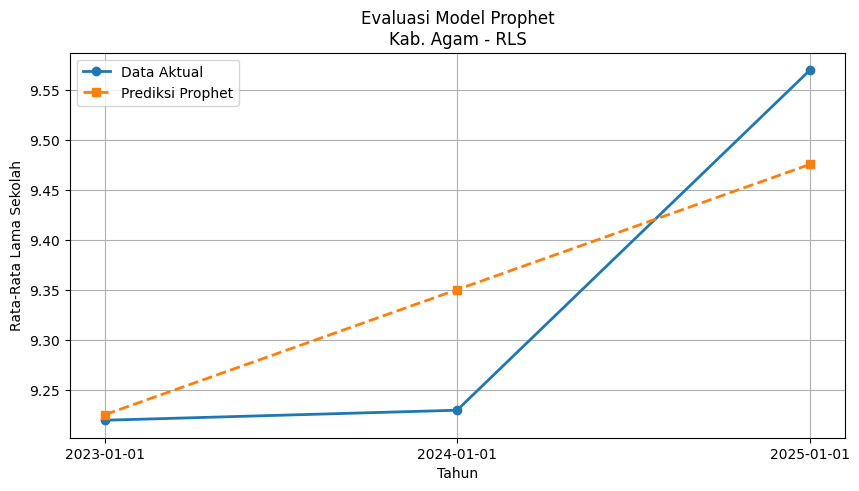

In [39]:
plt.figure(figsize=(10,5))

plt.plot(
    hasil["ds"],
    hasil["y"],
    marker="o",
    linewidth=2,
    label="Data Aktual"
)

plt.plot(
    hasil["ds"],
    hasil["Prediksi"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Prediksi Prophet"
)

plt.title(f"Evaluasi Model Prophet\n{kabupaten} - RLS")

plt.xlabel("Tahun")
plt.ylabel("Rata-Rata Lama Sekolah")

plt.xticks(hasil["ds"])

plt.grid(True)

plt.legend()

plt.show()

In [40]:
model = Prophet(
    growth="linear",
    changepoint_prior_scale=0.5,
    changepoint_range=0.95,
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)

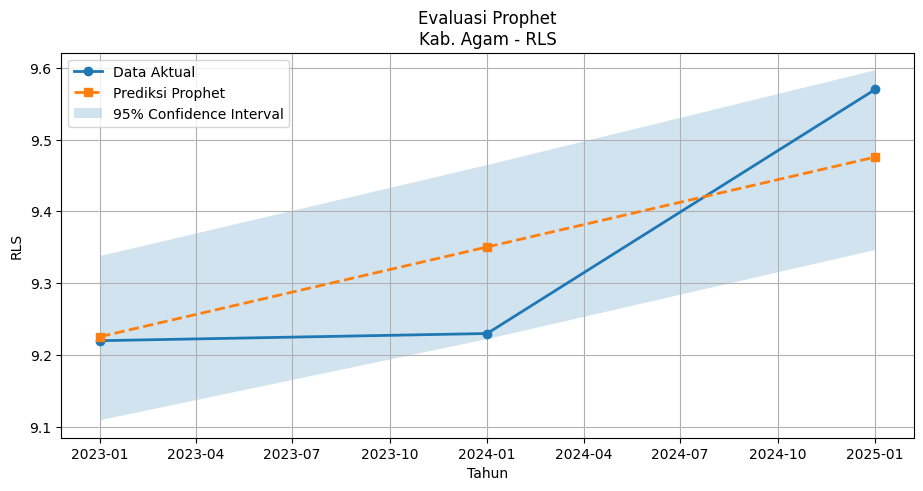

In [44]:
plt.figure(figsize=(11,5))

plt.plot(
    hasil["ds"],
    hasil["y"],
    marker="o",
    linewidth=2,
    label="Data Aktual"
)

plt.plot(
    hasil["ds"],
    hasil["Prediksi"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Prediksi Prophet"
)

plt.fill_between(
    hasil["ds"],
    forecast["yhat_lower"].values,
    forecast["yhat_upper"].values,
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title(f"Evaluasi Prophet\n{kabupaten} - RLS")

plt.xlabel("Tahun")
plt.ylabel("RLS")

plt.grid(True)

plt.legend()

plt.show()

Final build model dari GOY

In [46]:
from prophet import Prophet
import pandas as pd

def prophet_forecast(data, indikator, end_year=2035):

    # Persiapan data
    df_prophet = data[["Tahun", indikator]].copy()
    df_prophet.columns = ["ds", "y"]
    df_prophet["ds"] = pd.to_datetime(df_prophet["ds"].astype(str) + "-01-01")

    # Model Prophet
    model = Prophet(
        growth="linear",
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.5,
        changepoint_range=0.95
    )

    model.fit(df_prophet)

    # Membuat tahun sampai 2035
    future = pd.DataFrame({
        "ds": pd.date_range(
            start="2010-01-01",
            end=f"{end_year}-01-01",
            freq="YS"
        )
    })

    forecast = model.predict(future)

    forecast["Tahun"] = forecast["ds"].dt.year

    return forecast[[
        "Tahun",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]]

In [47]:
hasil = []

kabupaten_list = sorted(df["Kabupaten_Kota"].unique())

for kab in kabupaten_list:

    data = df[df["Kabupaten_Kota"] == kab]

    # Forecast RLS
    rls = prophet_forecast(data, "RLS")

    # Forecast AMH
    amh = prophet_forecast(data, "AMH")

    gabung = pd.DataFrame({
        "Kabupaten_Kota": kab,
        "Tahun": rls["Tahun"],
        "RLS": rls["yhat"],
        "RLS_lower": rls["yhat_lower"],
        "RLS_upper": rls["yhat_upper"],
        "AMH": amh["yhat"],
        "AMH_lower": amh["yhat_lower"],
        "AMH_upper": amh["yhat_upper"]
    })

    hasil.append(gabung)

forecast = pd.concat(
    hasil,
    ignore_index=True
)

forecast.head()

INFO:prophet:n_changepoints greater than number of observations. Using 14.
INFO:prophet:n_changepoints greater than number of observations. Using 14.
INFO:prophet:n_changepoints greater than number of observations. Using 14.
INFO:prophet:n_changepoints greater than number of observations. Using 14.
INFO:prophet:n_changepoints greater than number of observations. Using 14.
INFO:prophet:n_changepoints greater than number of observations. Using 14.
INFO:prophet:n_changepoints greater than number of observations. Using 14.
INFO:prophet:n_changepoints greater than number of observations. Using 14.
INFO:prophet:n_changepoints greater than number of observations. Using 14.
INFO:prophet:n_changepoints greater than number of observations. Using 14.
INFO:prophet:n_changepoints greater than number of observations. Using 14.
INFO:prophet:n_changepoints greater than number of observations. Using 14.
INFO:prophet:n_changepoints greater than number of observations. Using 14.
INFO:prophet:n_changepoin

,Kabupaten_Kota,Tahun,RLS,RLS_lower,RLS_upper,AMH,AMH_lower,AMH_upper
0,Kab. Agam,2010,7.56,7.56,7.56,98.03,98.03,98.03
1,Kab. Agam,2011,7.68,7.68,7.68,97.91,97.91,97.91
2,Kab. Agam,2012,7.91,7.91,7.91,98.04,98.04,98.04
3,Kab. Agam,2013,8.09,8.09,8.09,99.11,99.11,99.11
4,Kab. Agam,2014,8.10,8.10,8.10,99.48,99.48,99.48


In [52]:
actual = df.copy()

actual["Status"] = "Actual"

actual["RLS_lower"] = actual["RLS"]
actual["RLS_upper"] = actual["RLS"]

actual["AMH_lower"] = actual["AMH"]
actual["AMH_upper"] = actual["AMH"]

forecast = forecast[forecast["Tahun"] >= 2026]

forecast["Status"] = "Forecast"

education_forecast = pd.concat(
    [actual, forecast],
    ignore_index=True
)

education_forecast = education_forecast.sort_values(
    ["Kabupaten_Kota", "Tahun"]
).reset_index(drop=True)

In [53]:
print("Jumlah Data")

print(education_forecast.shape)

print()

print(education_forecast.groupby("Status").size())

print()

print(education_forecast["Tahun"].min())

print(education_forecast["Tahun"].max())

Jumlah Data
(494, 9)

Status
Actual      304
Forecast    190
dtype: int64

2010
2035


In [54]:
education_forecast.to_csv(
    "education_forecast.csv",
    index=False,
    encoding="utf-8-sig"
)

print("education_forecast.csv berhasil dibuat")

education_forecast.csv berhasil dibuat


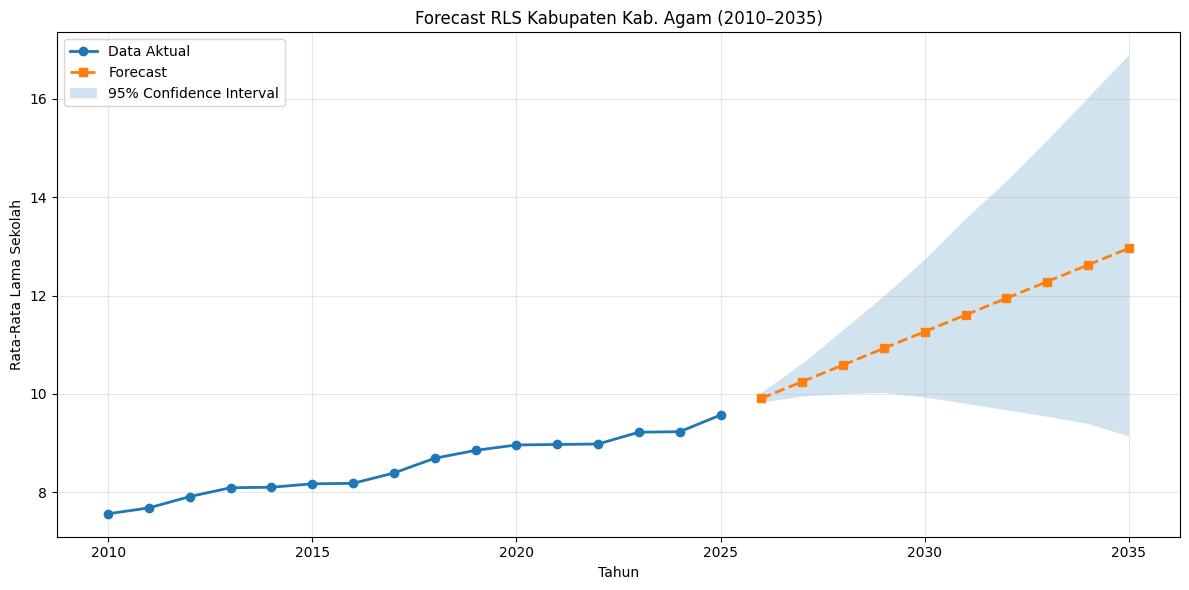

In [55]:
import matplotlib.pyplot as plt

kabupaten = "Kab. Agam"

plot_df = education_forecast[
    education_forecast["Kabupaten_Kota"] == kabupaten
]

plt.figure(figsize=(12,6))

actual = plot_df[plot_df["Status"] == "Actual"]
pred = plot_df[plot_df["Status"] == "Forecast"]

plt.plot(
    actual["Tahun"],
    actual["RLS"],
    marker="o",
    linewidth=2,
    label="Data Aktual"
)

plt.plot(
    pred["Tahun"],
    pred["RLS"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Forecast"
)

plt.fill_between(
    pred["Tahun"],
    pred["RLS_lower"],
    pred["RLS_upper"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title(f"Forecast RLS Kabupaten {kabupaten} (2010–2035)")
plt.xlabel("Tahun")
plt.ylabel("Rata-Rata Lama Sekolah")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()